## EXPLORATORY DATA ANALYSIS ON A DATASET

## 1.	Data Cleaning and Preparation:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Cardiotocographic.csv')

In [3]:
df.shape

(2126, 14)

In [4]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [6]:
# Missing values count
print(df.isnull().sum())

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [7]:
# Percentage of missing values
print(df.isnull().mean() * 100)

LB          0.987770
AC          0.940734
FM          0.000000
UC          0.000000
DL          0.000000
DS          0.987770
DP          0.987770
ASTV        0.000000
MSTV        0.000000
ALTV        0.000000
MLTV        0.987770
Width       0.987770
Tendency    0.987770
NSP         0.987770
dtype: float64


In [8]:
# Fill numeric columns with median
df.fillna(df.median(), inplace=True)

In [9]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [10]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [11]:
df.dtypes 

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [ ]:
# box plot for outliers detection

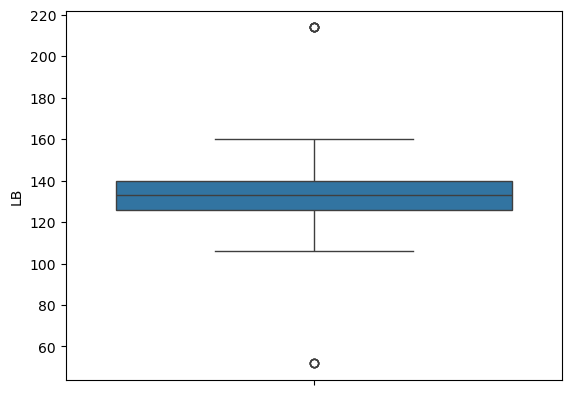

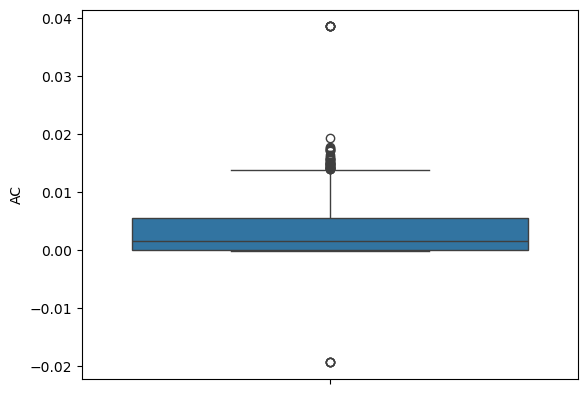

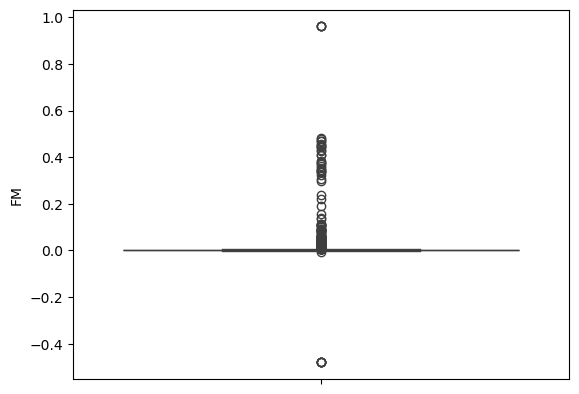

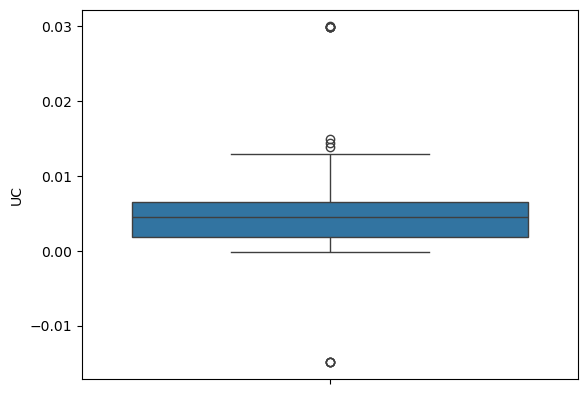

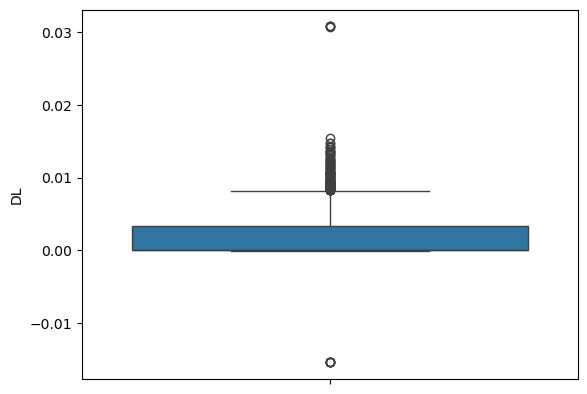

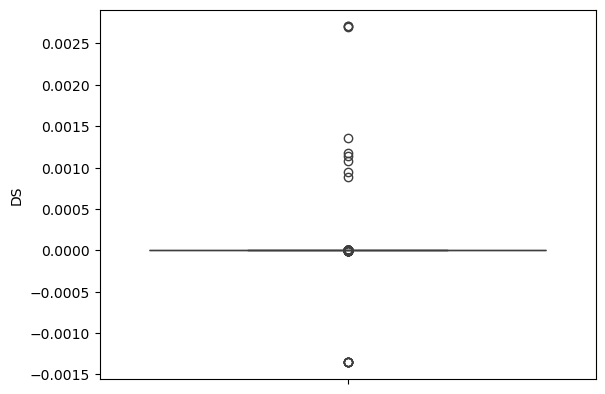

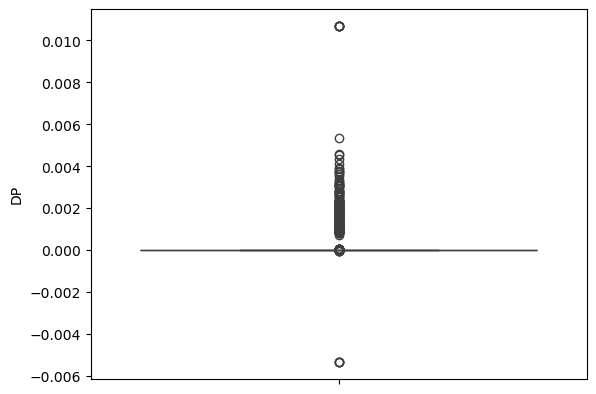

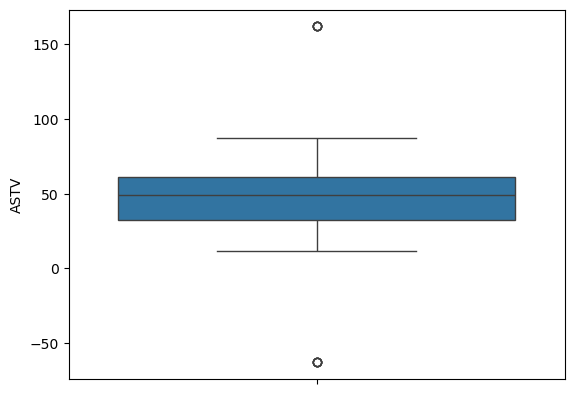

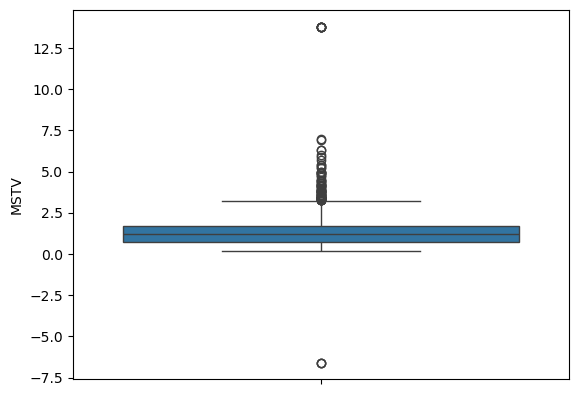

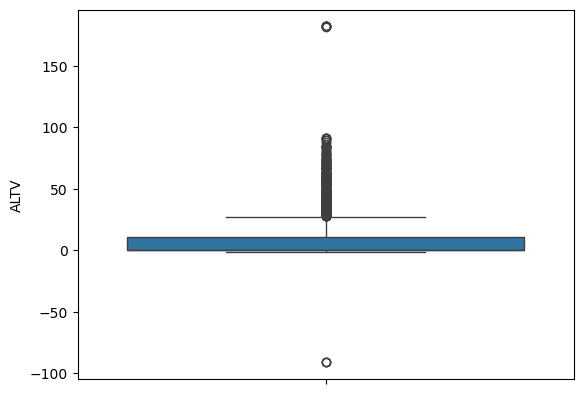

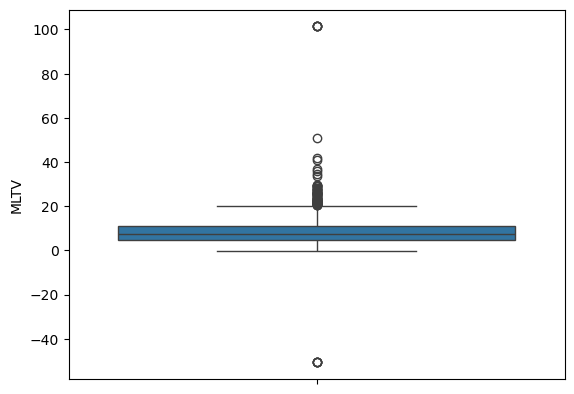

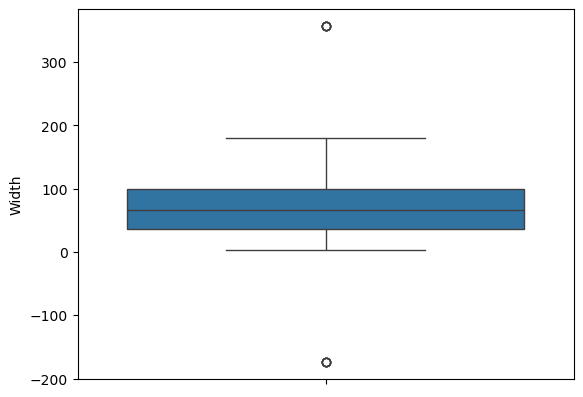

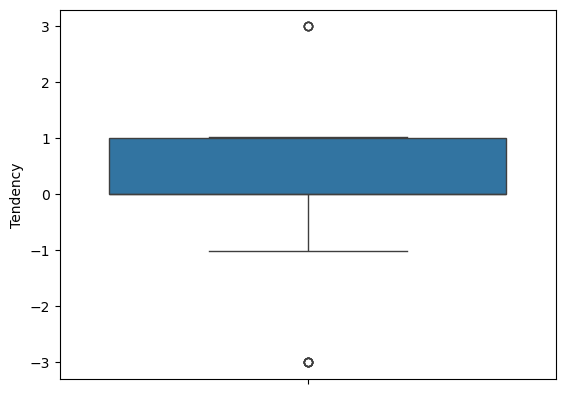

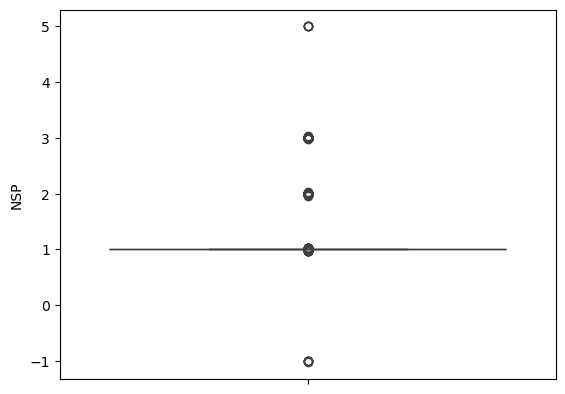

In [12]:
for i in df.columns:
    sns.boxplot(data=df,y=i)
    plt.show()

In [ ]:
# outlier capping

In [13]:
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

In [ ]:
# checking outliers are present or Not

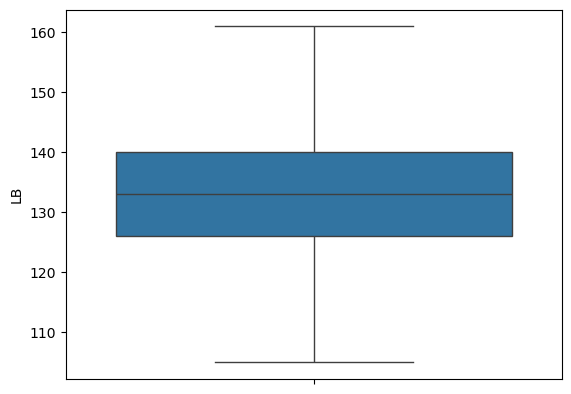

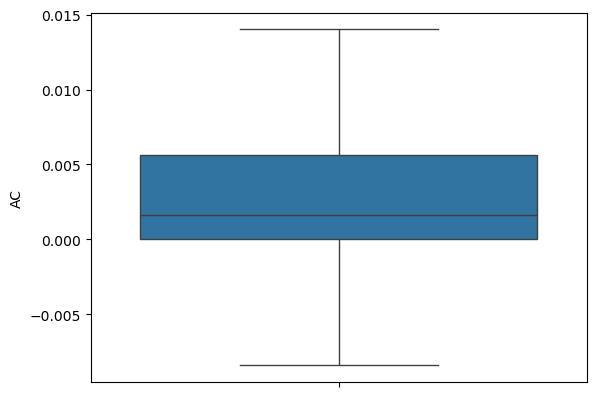

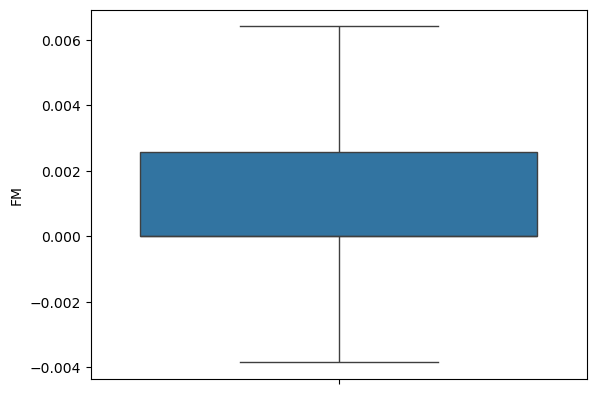

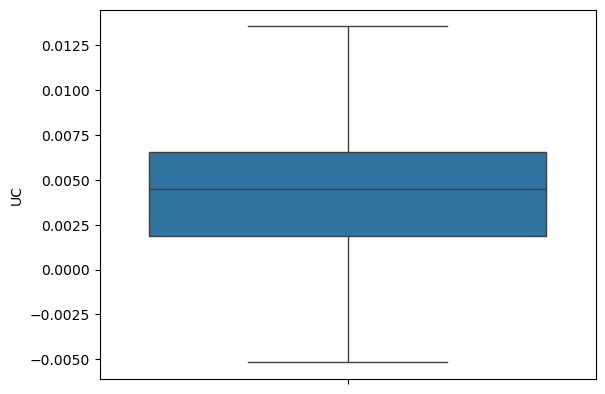

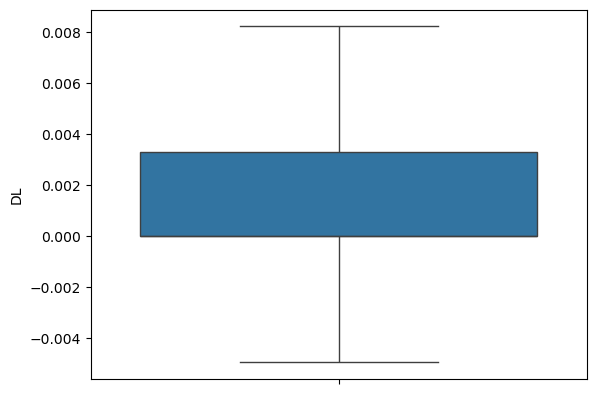

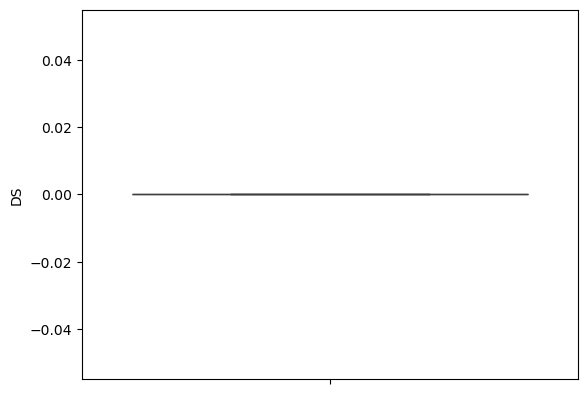

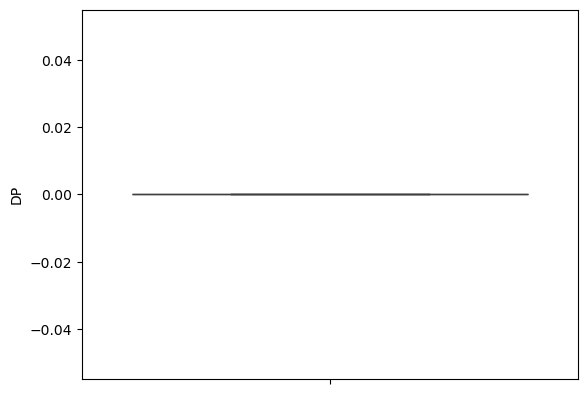

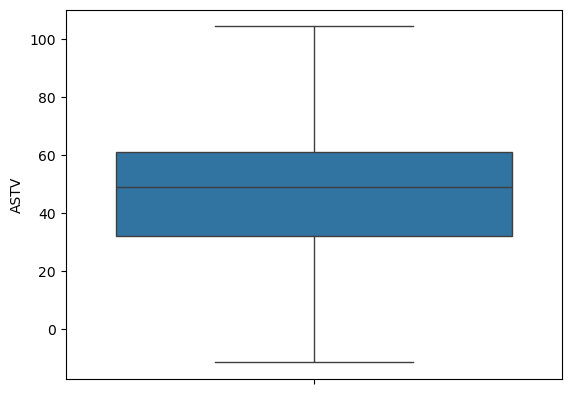

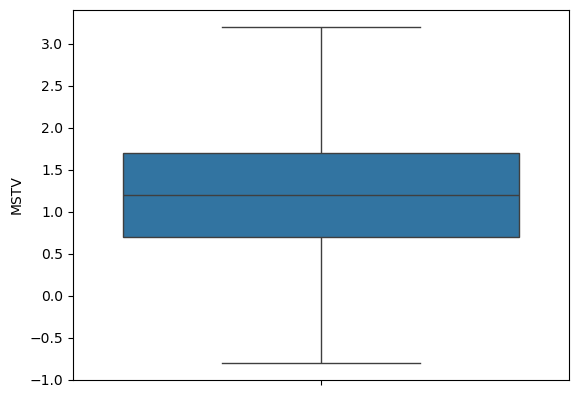

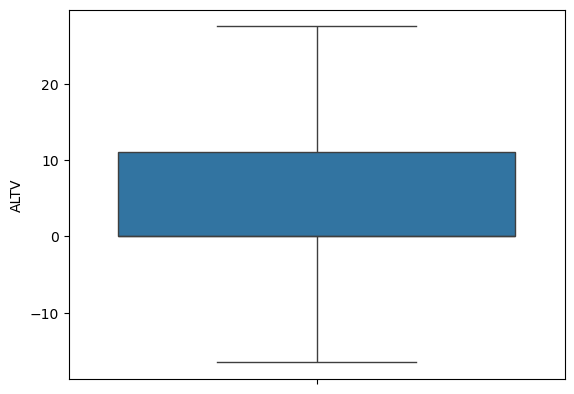

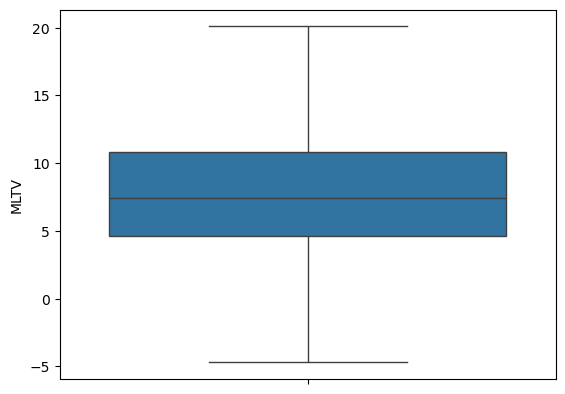

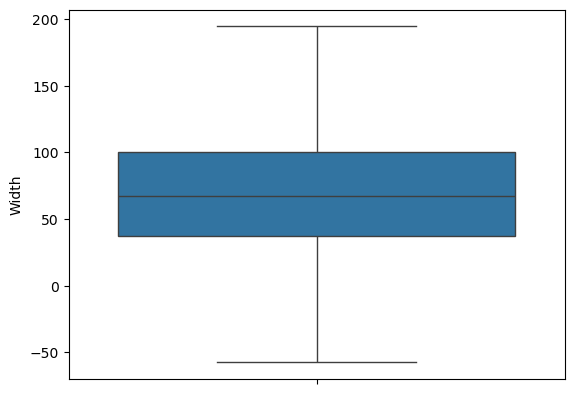

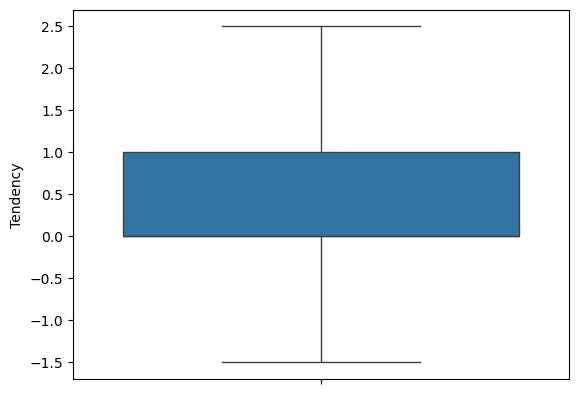

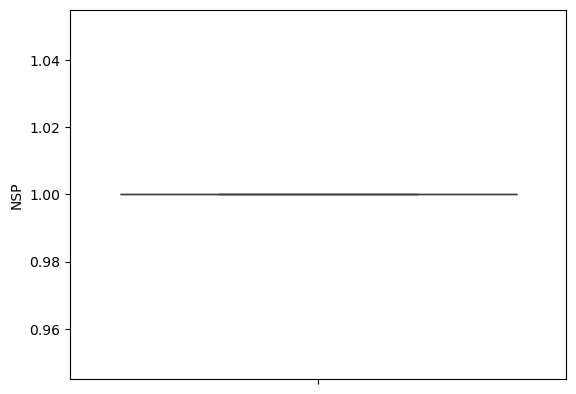

In [14]:
for i in df.columns:
    sns.boxplot(data=df,y=i)
    plt.show()

## 2.	Statistical Summary:

In [15]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0
mean,133.290331,0.003132,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.007471,70.287203,0.316537,1.0
std,9.930268,0.003828,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.047078,39.571995,0.622406,0.0
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [16]:
# Mean
mean = df.mean()

# Median
median = df.median()

# Standard Deviation
std = df.std()

# IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Combine all
summary = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Std Dev': std,
    'IQR': IQR
})

summary


,Mean,Median,Std Dev,IQR
LB,133.290331,133.000000,9.930268,14.000000
AC,0.003132,0.001634,0.003828,0.005606
FM,0.001568,0.000000,0.002485,0.002567
UC,0.004362,0.004484,0.003001,0.004685
DL,0.001770,0.000000,0.002668,0.003289
DS,0.000000,0.000000,0.000000,0.000000
DP,0.000000,0.000000,0.000000,0.000000
ASTV,46.981873,49.000000,17.612745,29.000000
MSTV,1.304644,1.200000,0.781091,1.000000
ALTV,6.691678,0.000000,10.378400,11.000000


In [17]:
# Highlight any interesting findings from this summary.

## 3.	Data Visualization:

In [ ]:
# Histogram representation

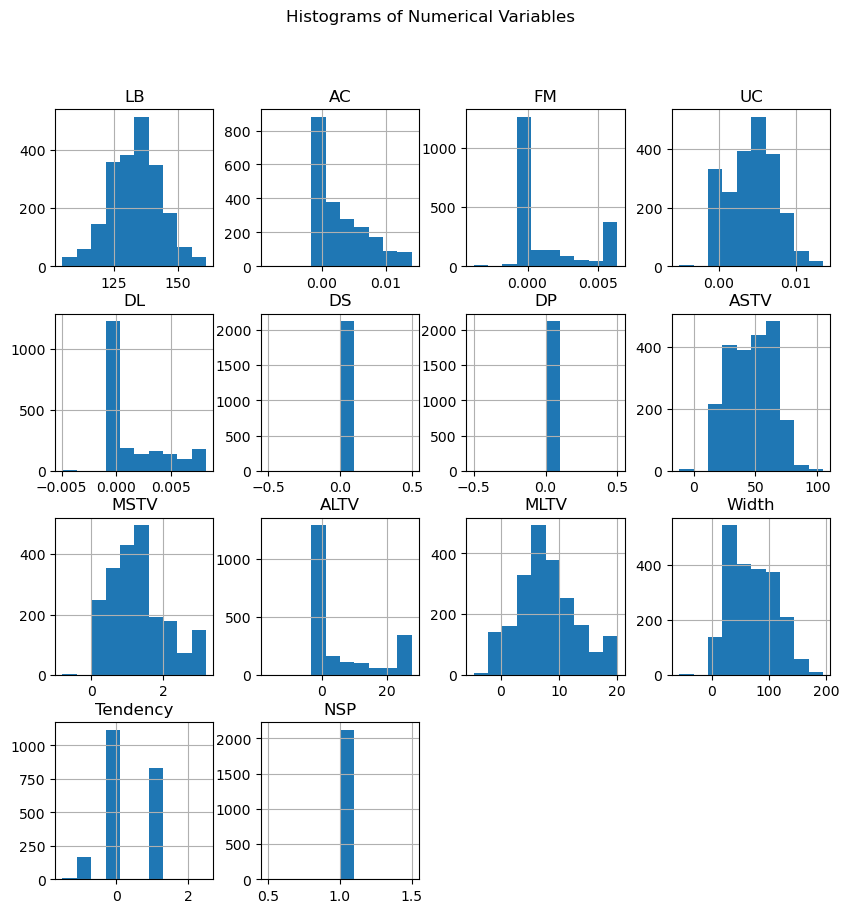

In [18]:
df.hist(figsize=(10, 10))
plt.suptitle("Histograms of Numerical Variables")
plt.show()

In [ ]:
# box plot

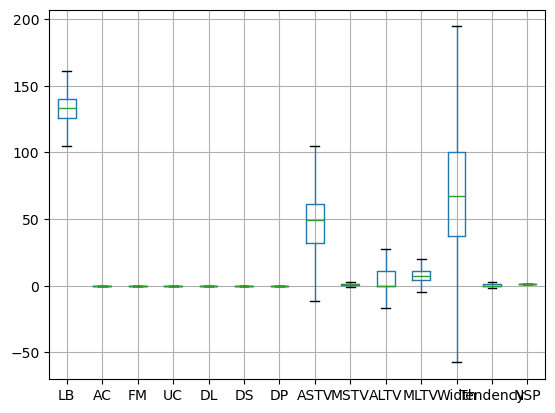

In [19]:
df.boxplot()
plt.show()

In [20]:
# NO categorical variables for visualize the  bar charts or pie charts

In [21]:
# correlation heatmap

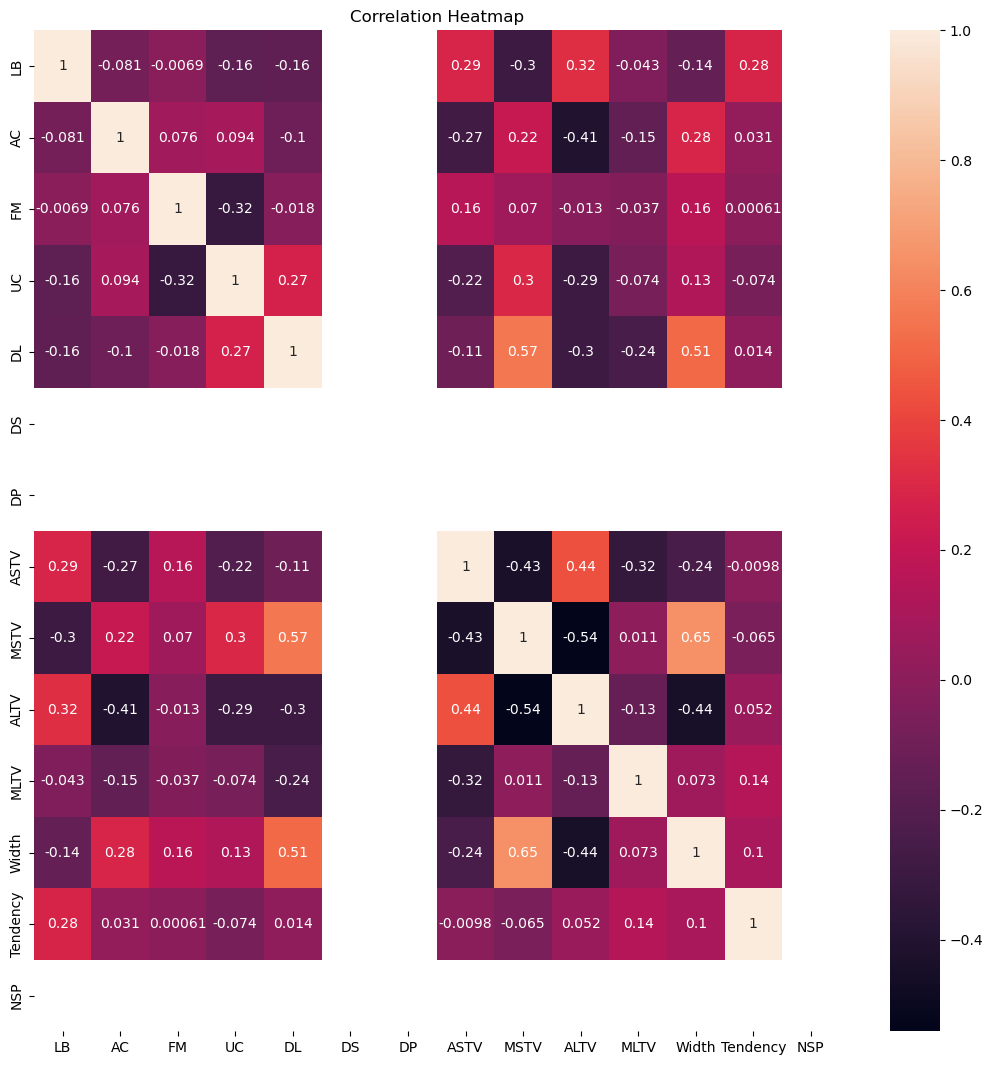

In [22]:
plt.figure(figsize=(13, 13))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# scatter plots(relationship between two numerical variables)

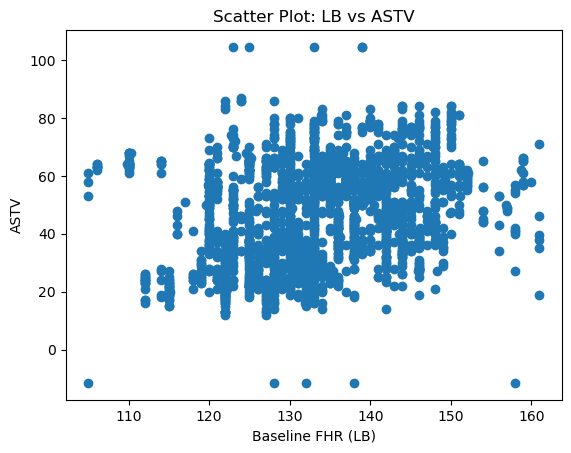

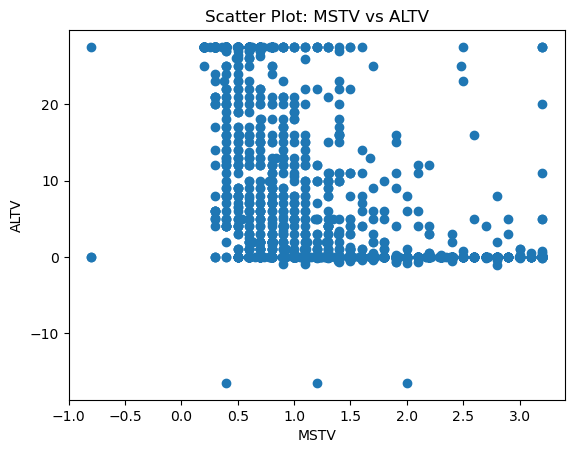

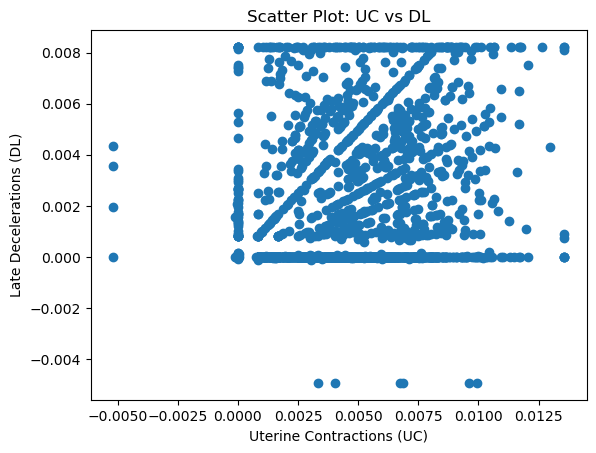

In [24]:
# LB vs ASTV
plt.figure()
plt.scatter(df['LB'], df['ASTV'])
plt.xlabel("Baseline FHR (LB)")
plt.ylabel("ASTV")
plt.title("Scatter Plot: LB vs ASTV")
plt.show()

# MSTV vs ALTV
plt.figure()
plt.scatter(df['MSTV'], df['ALTV'])
plt.xlabel("MSTV")
plt.ylabel("ALTV")
plt.title("Scatter Plot: MSTV vs ALTV")
plt.show()

# UC vs DL
plt.figure()
plt.scatter(df['UC'], df['DL'])
plt.xlabel("Uterine Contractions (UC)")
plt.ylabel("Late Decelerations (DL)")
plt.title("Scatter Plot: UC vs DL")
plt.show()


In [25]:
# pair plot

<Figure size 1300x1300 with 0 Axes>

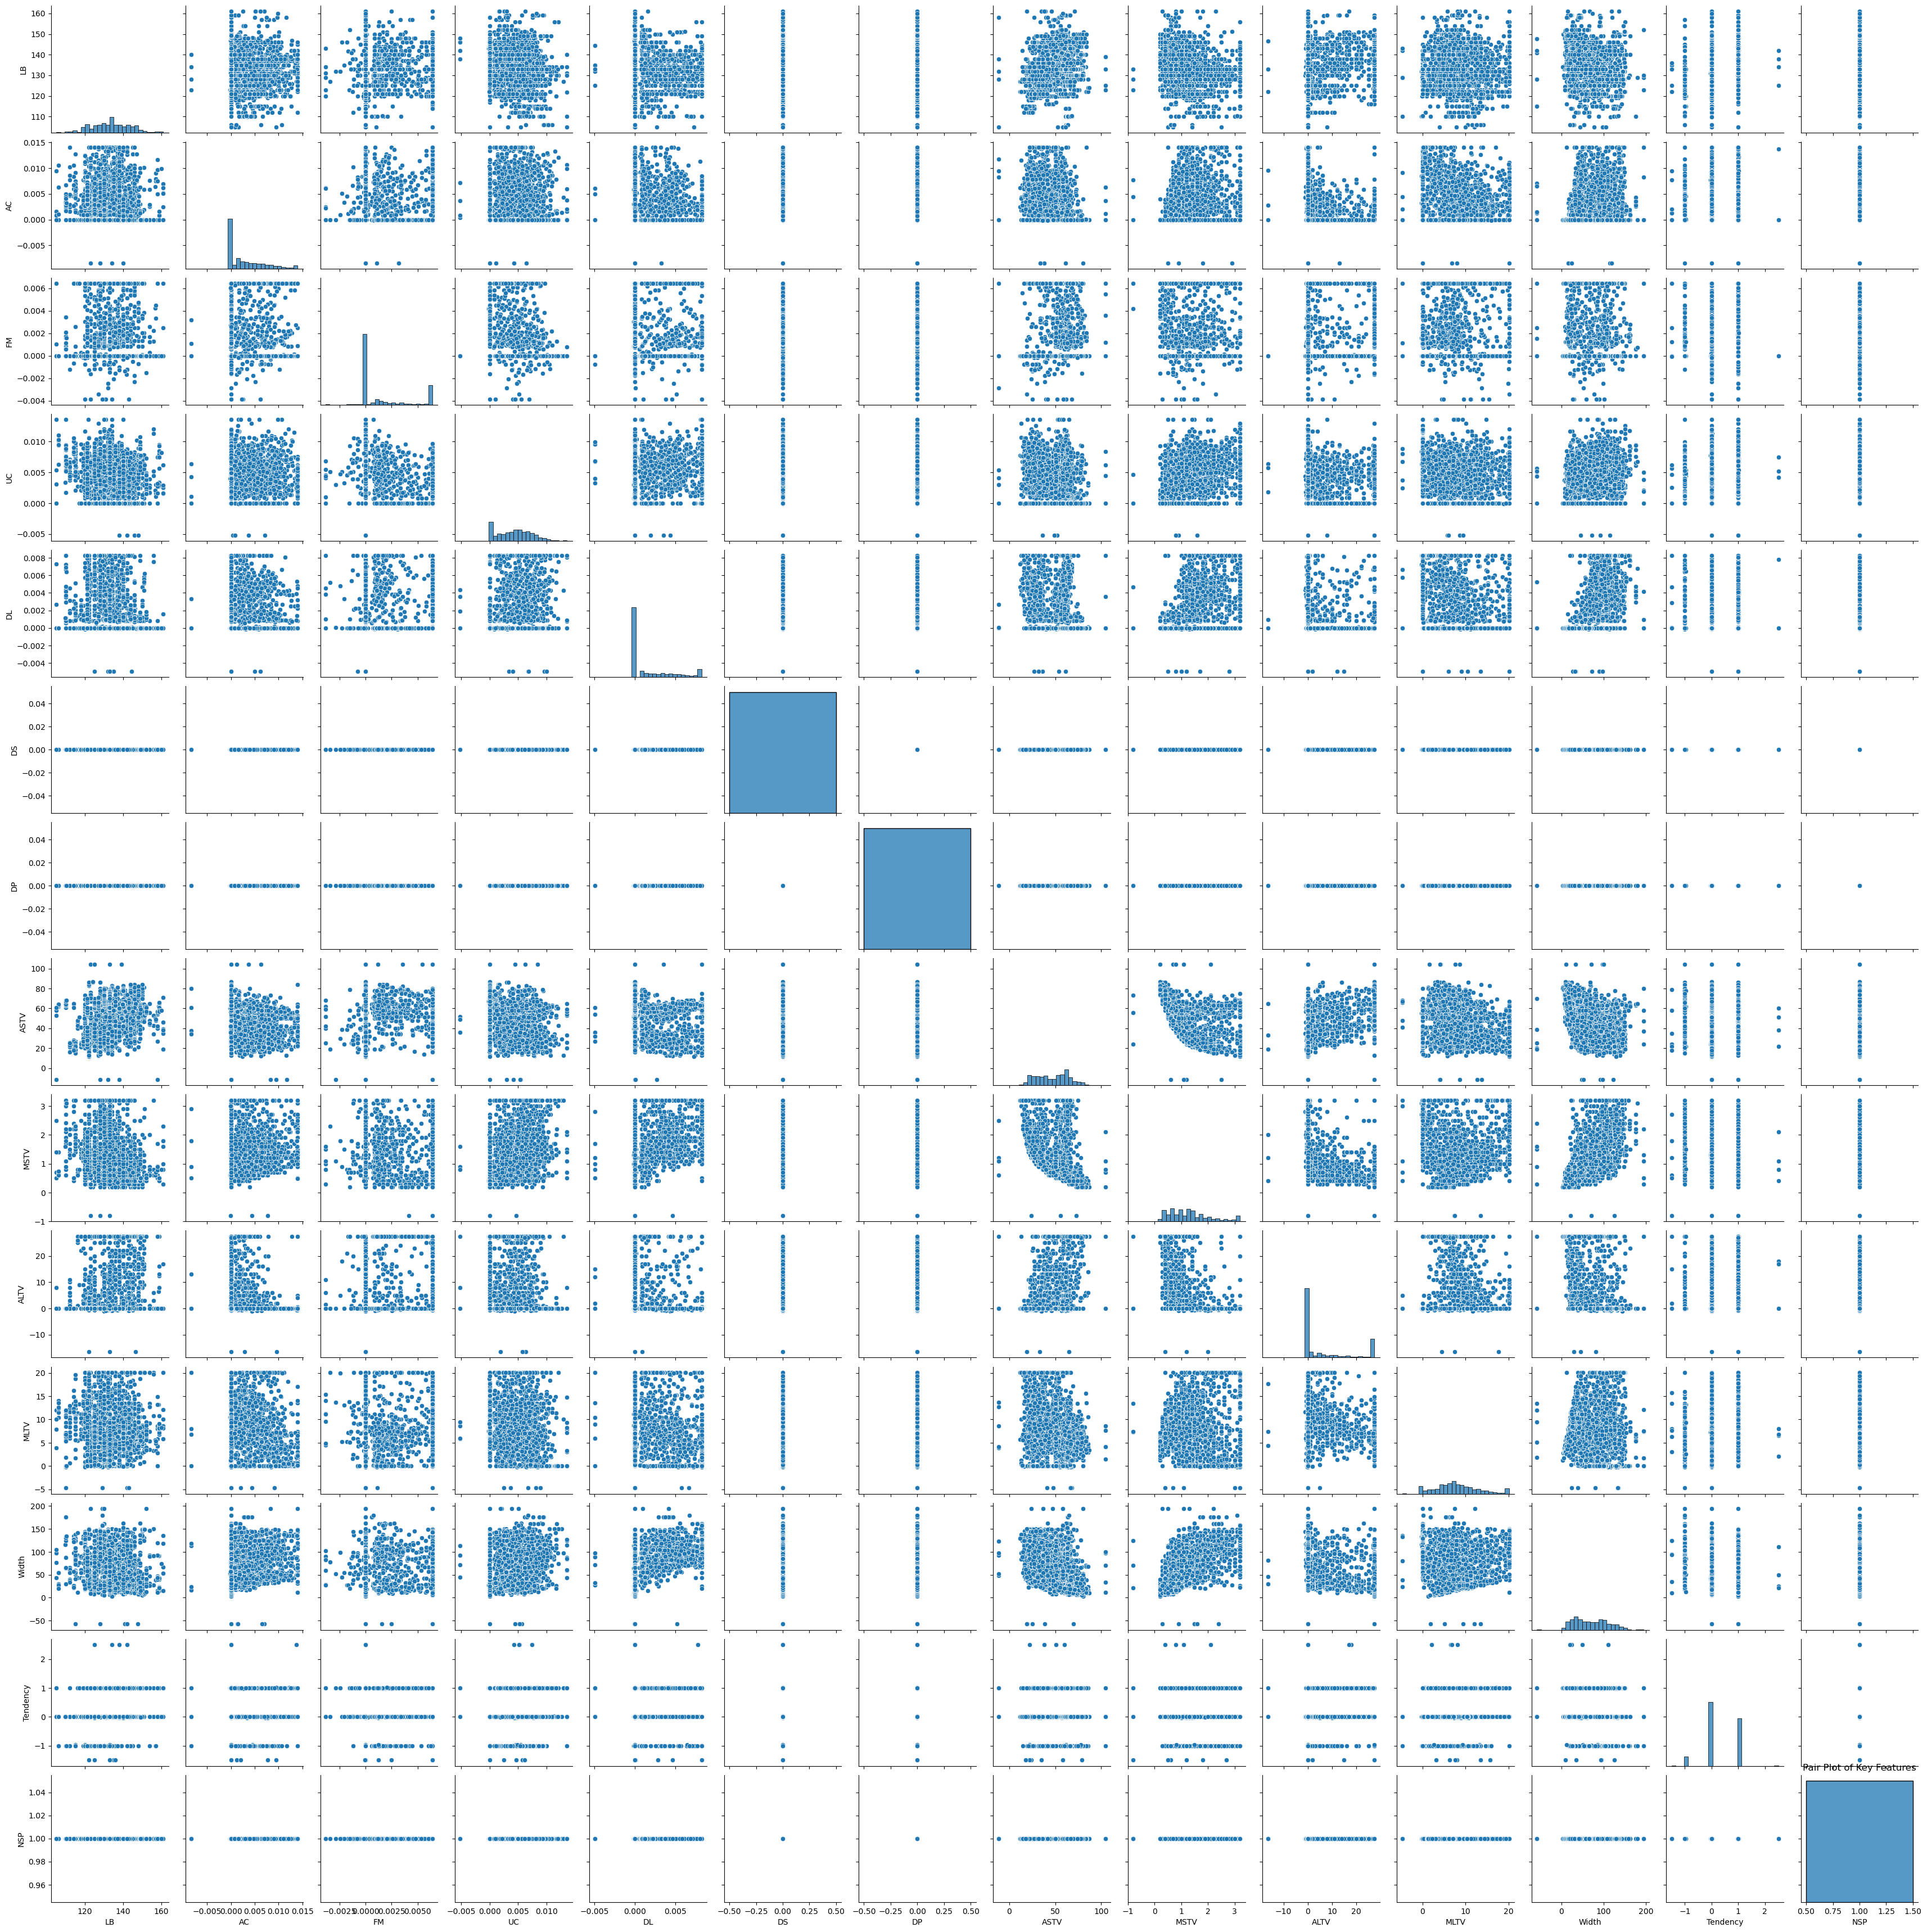

In [26]:
plt.figure(figsize=(13, 13))
sns.pairplot(data=df)
plt.title("Pair Plot of Key Features")
plt.show()

In [27]:
# violin plot

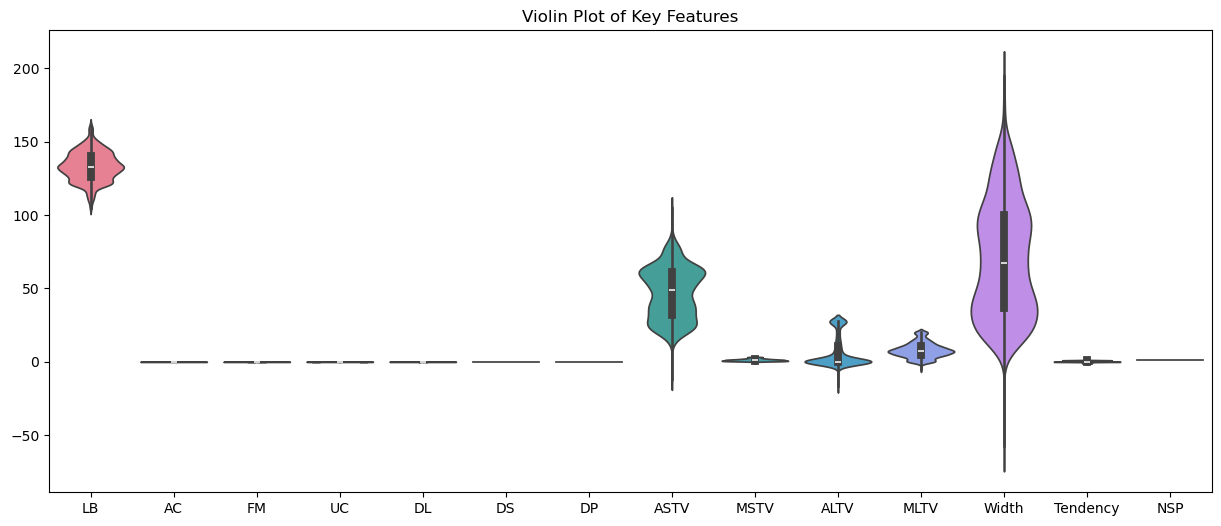

In [28]:
plt.figure(figsize=(15, 6))
sns.violinplot(data=df)
plt.title("Violin Plot of Key Features")
plt.show()

## 4.	Pattern Recognition and Insights:

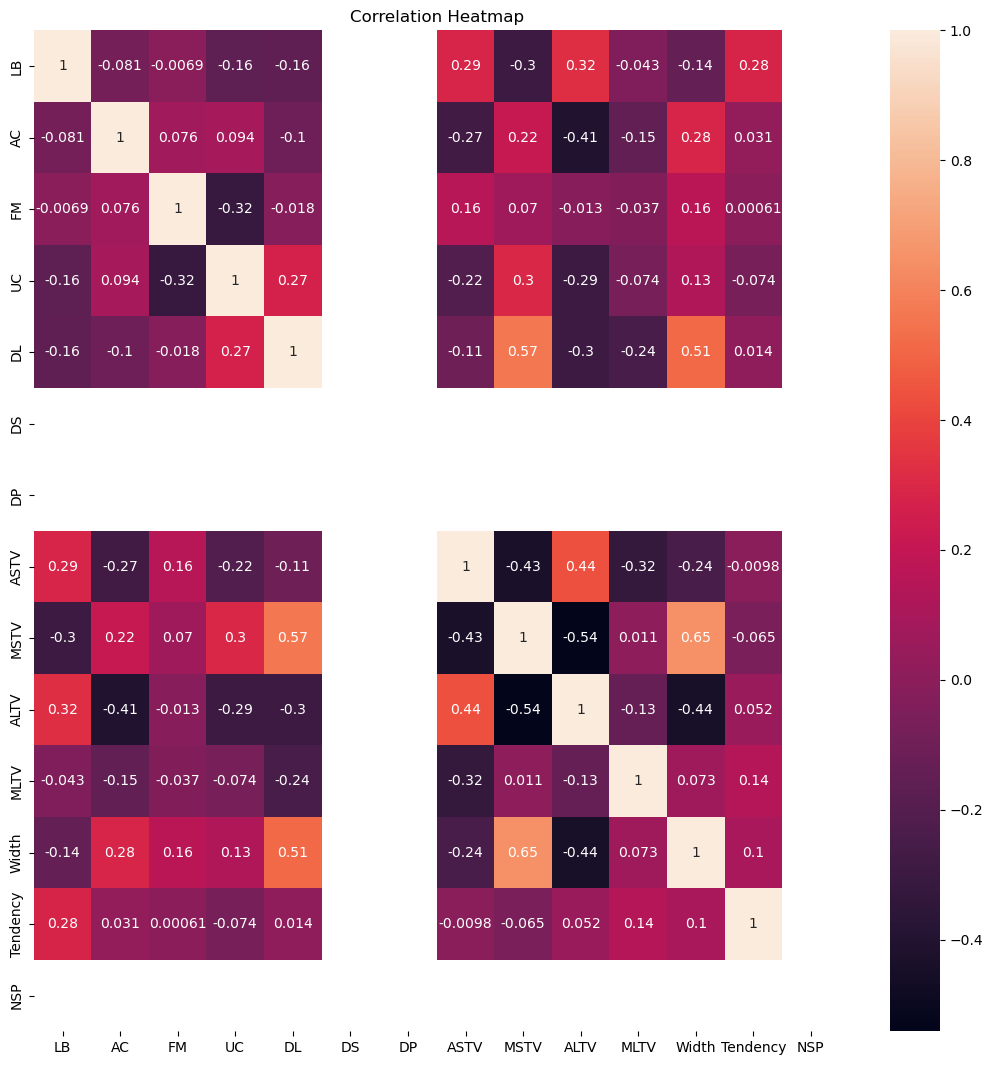

In [29]:
plt.figure(figsize=(13, 13))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
corr_matrix = df.corr()

# Top correlations (excluding self-correlation)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.drop_duplicates().head(10)

Width     MSTV     0.645744
DL        MSTV     0.566340
Width     DL       0.514538
ALTV      ASTV     0.439040
          LB       0.322431
MSTV      UC       0.297843
ASTV      LB       0.285623
AC        Width    0.283749
Tendency  LB       0.280796
DL        UC       0.268605
dtype: float64

## 5.	Conclusion: